# Load Data

In [1]:
TABLE = "price_features"
CALENDAR = "no_calendar"

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [4]:
df = pull_calendar_table(
    table_name = TABLE,
    calendar = CALENDAR
)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table


In [5]:
df.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return_no_calendar', 'log_return_no_calendar',
       'cumulative_returns_no_calendar', 'rolling_7d_return_no_calendar',
       'rolling_30d_return_no_calendar', 'lag_1_return_no_calendar',
       'lag_5_return_no_calendar', 'moving_avg_20_no_calendar',
       'moving_avg_50_no_calendar', 'price_vs_ma20_no_calendar',
       'relative_volume_no_calendar', 'rolling_30d_volatility_no_calendar',
       'drawdown_no_calendar', 'target_next_day_return_no_calendar',
       'target_direction_no_calendar'],
      dtype='str')

In [6]:
table_count = 0
graph_count = 0
matrix_count = 0
figure_count = 0

# Feature Return Correlation Heamaps

Figure 1: Feature-Return Corrrelation Heatmaps


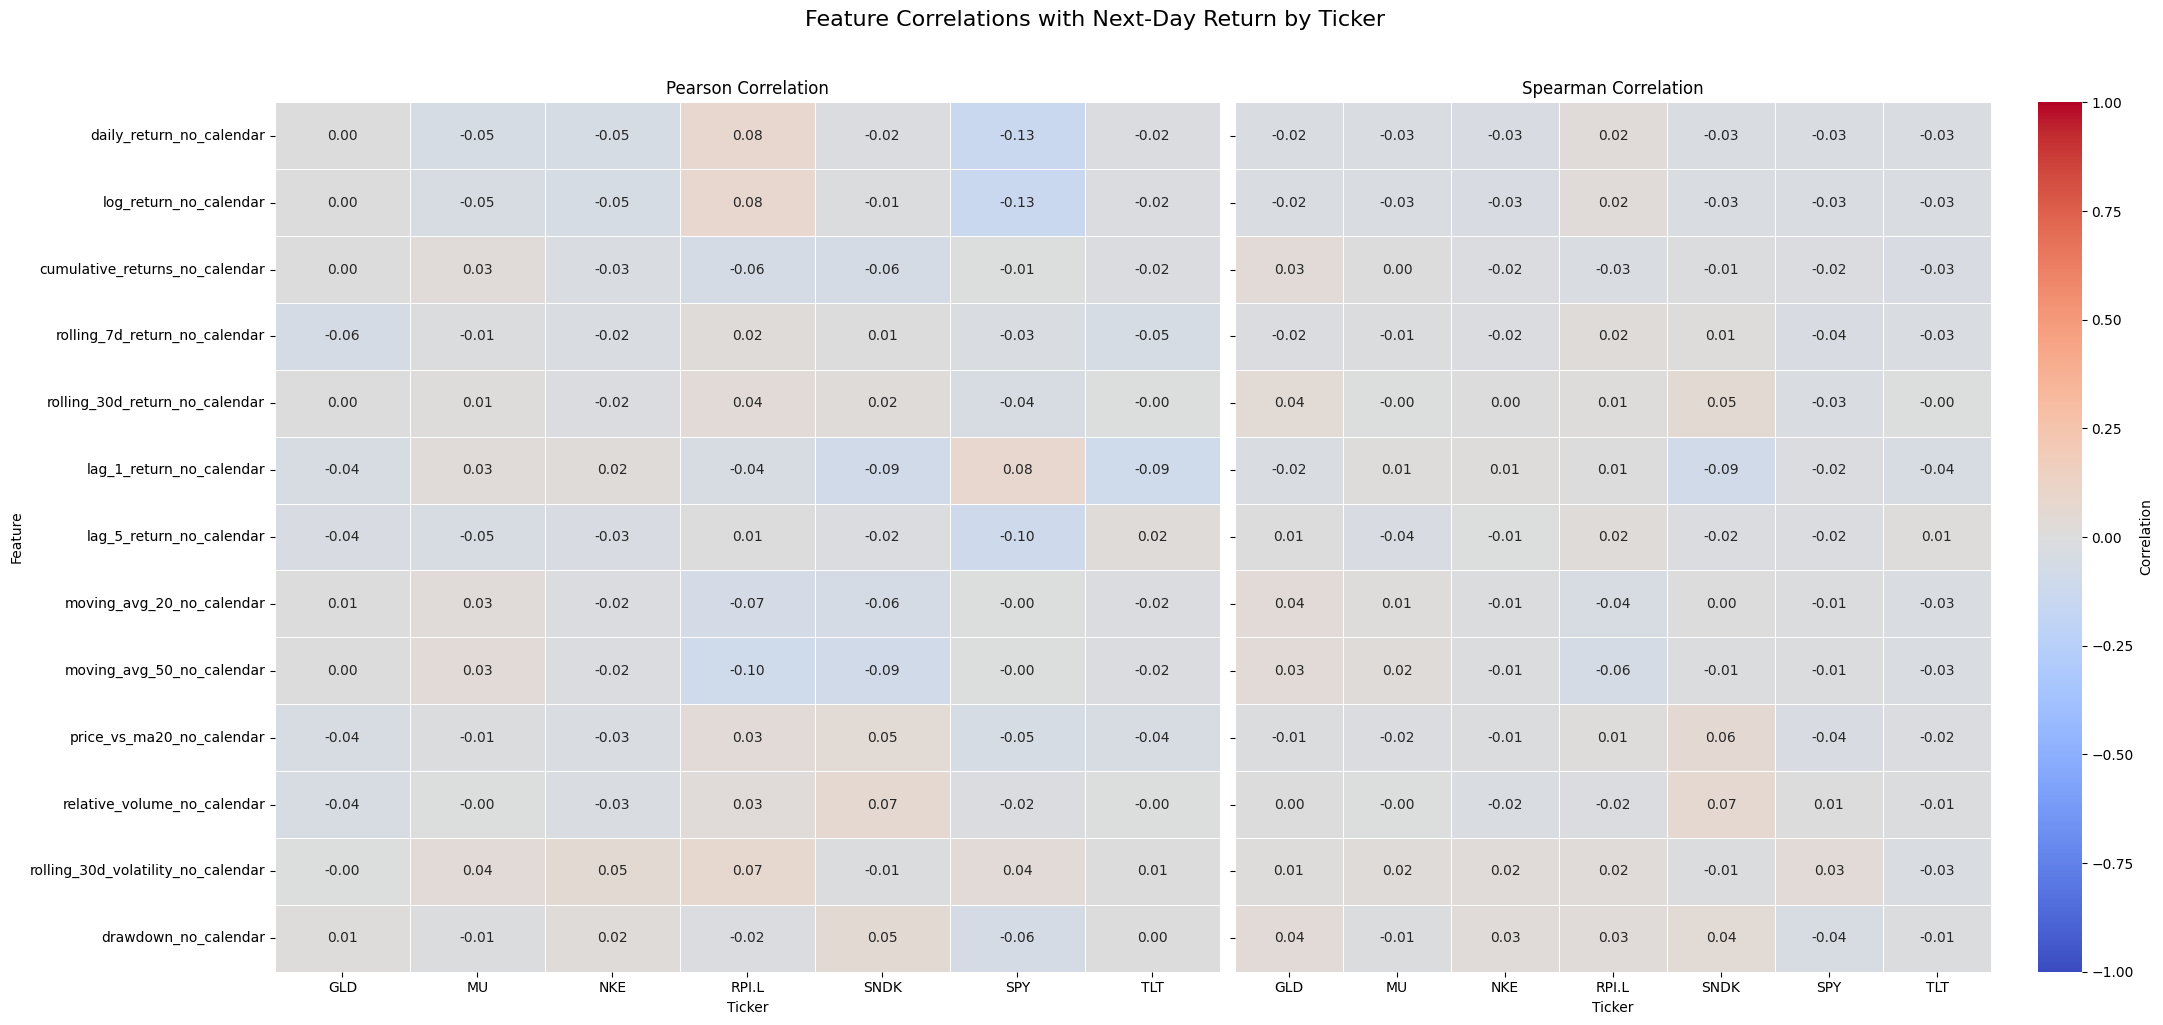

Figure 2: Feature-Return Corrrelation Heatmaps (Minimised Scale)


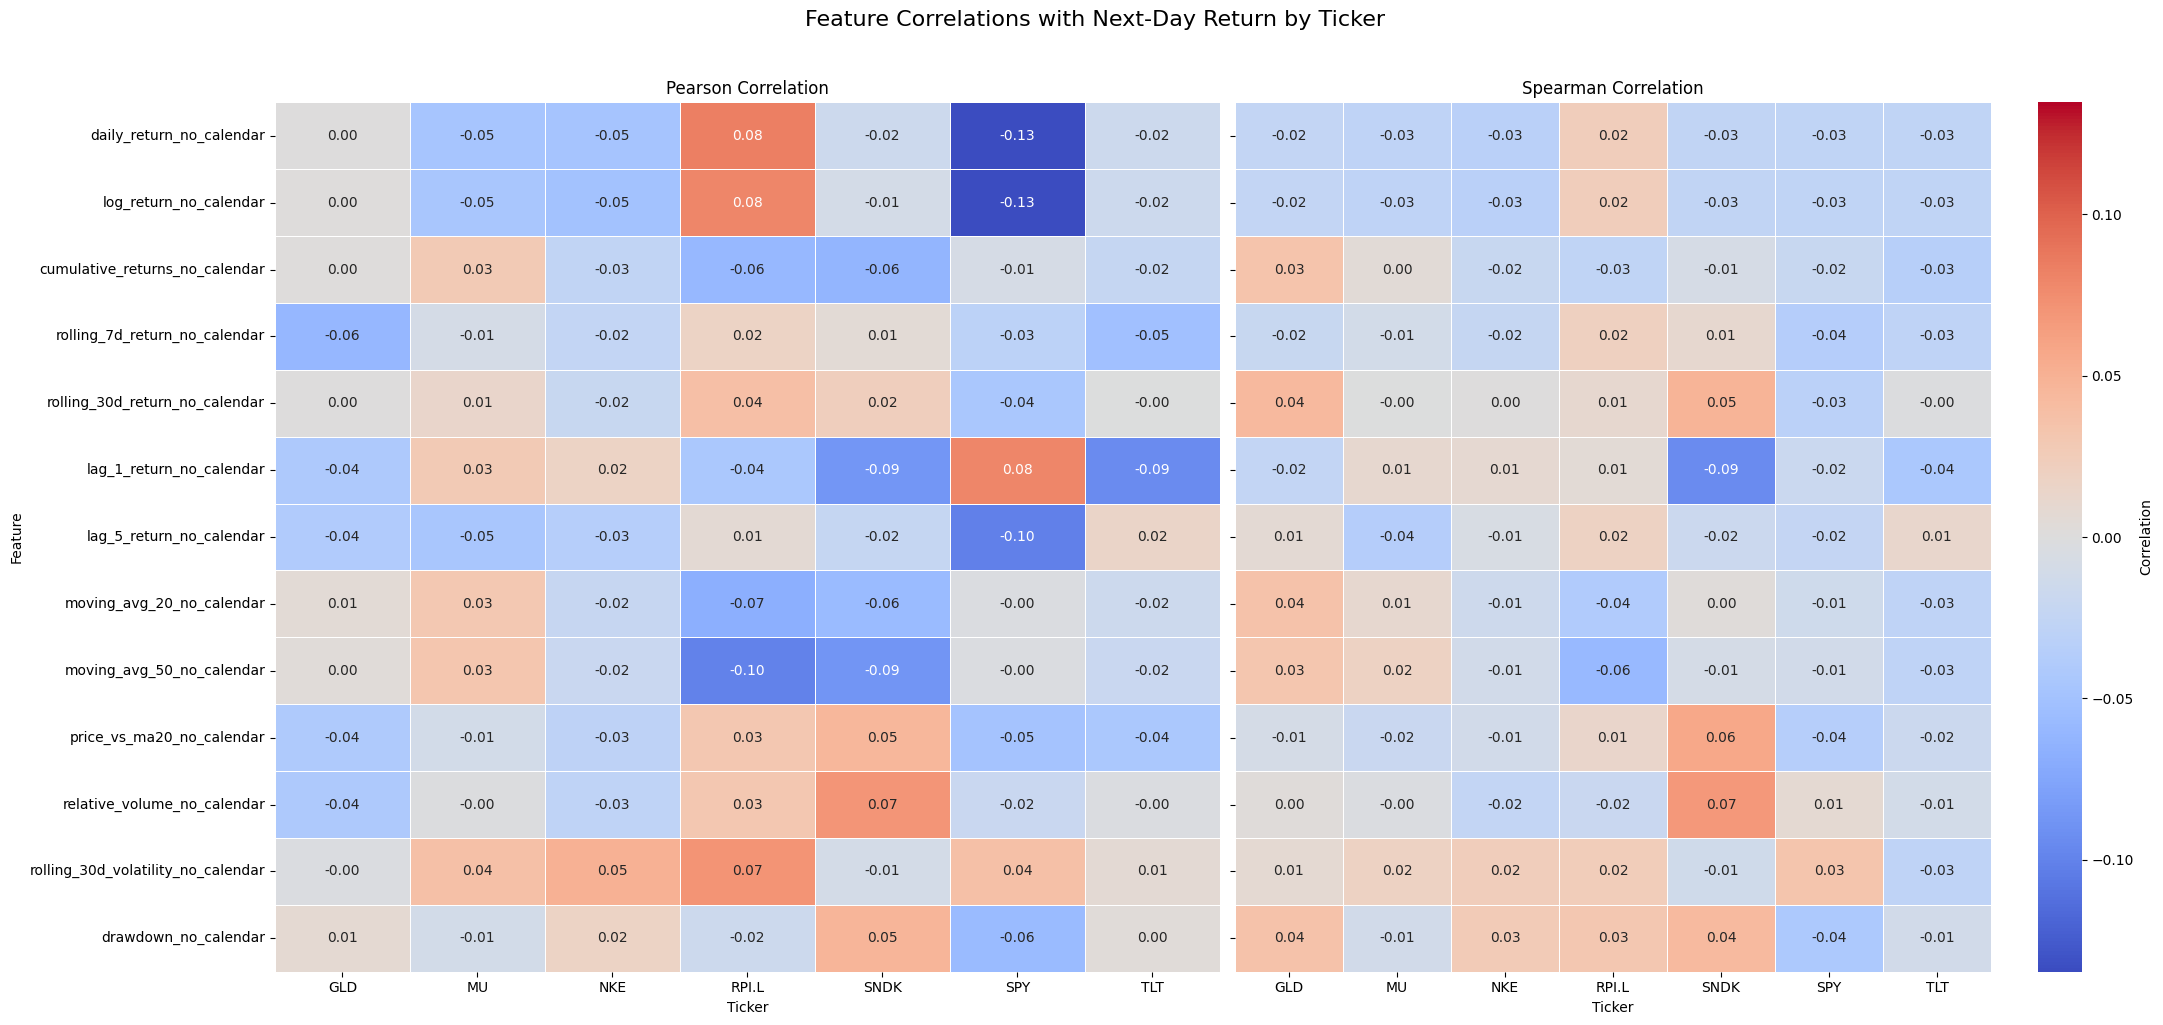

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_1 = df.copy()

keep_colunmns = [
    column 
    for column in df_1.columns
    if column == "ticker" or column.endswith(f"_{CALENDAR}")
]

df_1 = df_1[keep_colunmns]
df_1 = df_1.drop(columns=[f"target_direction_{CALENDAR}"], errors="ignore")

target = f"target_next_day_return_{CALENDAR}"
ticker = "ticker"

pearson_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="pearson", numeric_only=True)[target]
        .drop(target)
        .rename_axis("variable")
        )
    for ticker_value, group in df_1.groupby(ticker)
})

spearman_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="spearman", numeric_only=True)[target]
        .drop(target)
        .rename_axis("variable")
        )
    for ticker_value, group in df_1.groupby(ticker)
})

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(22,10),
    sharey=True
)

sns.heatmap(
    pearson_corr,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar=False
)

axes[0].set_title("Pearson Correlation")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Feature")

sns.heatmap(
    spearman_corr,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

axes[1].set_title("Spearman Correlation")
axes[1].set_xlabel("Ticker")
axes[1].set_ylabel("")

fig.suptitle(
    "Feature Correlations with Next-Day Return by Ticker",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

figure_count += 1
print(f"Figure {figure_count}: Feature-Return Corrrelation Heatmaps")
plt.show()


s_scale = spearman_corr.abs().max().max()
p_scale =  pearson_corr.abs().max().max()

scale = max(s_scale, p_scale)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(22,10),
    sharey=True
)

sns.heatmap(
    pearson_corr,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-scale,
    vmax=scale,
    linewidths=0.5,
    cbar=False
)

axes[0].set_title("Pearson Correlation")
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Feature")

sns.heatmap(
    spearman_corr,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-scale,
    vmax=scale,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

axes[1].set_title("Spearman Correlation")
axes[1].set_xlabel("Ticker")
axes[1].set_ylabel("")

fig.suptitle(
    "Feature Correlations with Next-Day Return by Ticker",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

figure_count += 1
print(f"Figure {figure_count}: Feature-Return Corrrelation Heatmaps (Minimised Scale)")
plt.show()

Figure 1 shows no significant correlations on normal -1 to +1 scale.

Figure 2 highlights the stronger correlaions of the weak correlations. General trend of stronger pearson correlations compared to pearson for most assets but GLD indicating stronger influence of outliers and less co-movements of features and target. Some relationships such as SNDK lag-1-return have consistent relationships across both measures.



In [8]:
combined_corr = pearson_corr.merge(
    spearman_corr,
    left_index = True,
    right_index = True,
    how = "inner"
)

combined_corr = combined_corr.rename(
    columns = lambda col: col.replace("_x", "_pearson").replace("_y", "_spearman")
)

combined_corr = (
    combined_corr
    .assign(
        max_absolute_corr = lambda x:
            x[combined_corr.columns].abs().max(axis=1),

        max_corr_ticker = lambda x:
            x[combined_corr.columns].abs().idxmax(axis=1),

        positive_corr_count = lambda x:
            x[combined_corr.columns].gt(0).sum(axis=1),

        negative_corr_count = lambda x:
            x[combined_corr.columns].lt(0).sum(axis=1)
    )
)

pearson_corr = (
    pearson_corr
    .assign(
        med_abs_pearson_corr = lambda x:
            x[pearson_corr.columns].abs().median(axis=1),
        )
    )

spearman_corr = (
    spearman_corr
    .assign(
        med_abs_spearman_corr = lambda x:
            x[spearman_corr.columns].abs().median(axis=1),
        )
    )

summary_df = pd.concat(
    [combined_corr[["max_absolute_corr", "max_corr_ticker", "positive_corr_count", "negative_corr_count"]], 
     pearson_corr[["med_abs_pearson_corr"]], 
     spearman_corr[["med_abs_spearman_corr"]]],
    axis=1,
    join="inner"
)

rename_map = {
    "max_absolute_corr": "Max Absolute\nCorrelation",
    "max_corr_ticker": "Ticker Of\nMaximum",
    "positive_corr_count": "Positive Correlation\n Count",
    "negative_corr_count": "Negative Correlation\n Count",
    "med_abs_pearson_corr": "Median Absolute\n Pearson Correlation",
    "med_abs_spearman_corr": "Median Absolute\n Spearman Correlation"
}

column_order = [
    "Median Absolute\n Pearson Correlation",
    "Median Absolute\n Spearman Correlation",
    "Max Absolute\nCorrelation",
    "Ticker Of\nMaximum",
    "Positive Correlation\n Count",
    "Negative Correlation\n Count"
]

summary_table = (
    summary_df
    .rename(columns=rename_map)
    .loc[:, column_order]
    .round(2)
    .reset_index()
)

count_cols = [
    "Positive Correlation\n Count",
    "Negative Correlation\n Count"
]

decimal_cols =[
    "Median Absolute\n Pearson Correlation",
    "Median Absolute\n Spearman Correlation",
    "Max Absolute\nCorrelation"
]

styled_table = (
    summary_table.style
    .format("{:.2f}", subset=decimal_cols)
    .format("{:.0f}", subset=count_cols)
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre"),
                ("text-align", "right"),
                ("vertical-align", "middle"),
                ("min-width", "120px"),
            ],
        }
    ])
    .hide(axis="index")
)

table_count += 1
print(f"Table {table_count}: Ranked Feature-Return Relationship Summary")
styled_table

Table 1: Ranked Feature-Return Relationship Summary


variable,Median Absolute Pearson Correlation,Median Absolute Spearman Correlation,Max Absolute Correlation,Ticker Of Maximum,Positive Correlation Count,Negative Correlation Count
daily_return_no_calendar,0.05,0.03,0.13,SPY_pearson,3,11
log_return_no_calendar,0.05,0.03,0.13,SPY_pearson,3,11
cumulative_returns_no_calendar,0.03,0.02,0.06,SNDK_pearson,4,10
rolling_7d_return_no_calendar,0.02,0.02,0.06,GLD_pearson,4,10
rolling_30d_return_no_calendar,0.02,0.01,0.05,SNDK_spearman,8,6
lag_1_return_no_calendar,0.04,0.02,0.09,TLT_pearson,6,8
lag_5_return_no_calendar,0.03,0.02,0.10,SPY_pearson,5,9
moving_avg_20_no_calendar,0.02,0.01,0.07,RPI.L_pearson,5,9
moving_avg_50_no_calendar,0.02,0.02,0.10,RPI.L_pearson,4,10
price_vs_ma20_no_calendar,0.04,0.02,0.06,SNDK_spearman,4,10


Table 1 supports previous evidence where there are no strong signals. Strongest signals are seen with SPY daily_return and log_return indicating short term momentum. Generally, there are more negative correlations indicating an inverse relationship with most features and the target, however, volatility and drawdown show a greater tendency toward positive co-movements suggesting larger drawdowns and higher volaitlity are related to greater target returns.

# Directional Separation Heatmap

Figure 3: Directional-Separation Heatmap


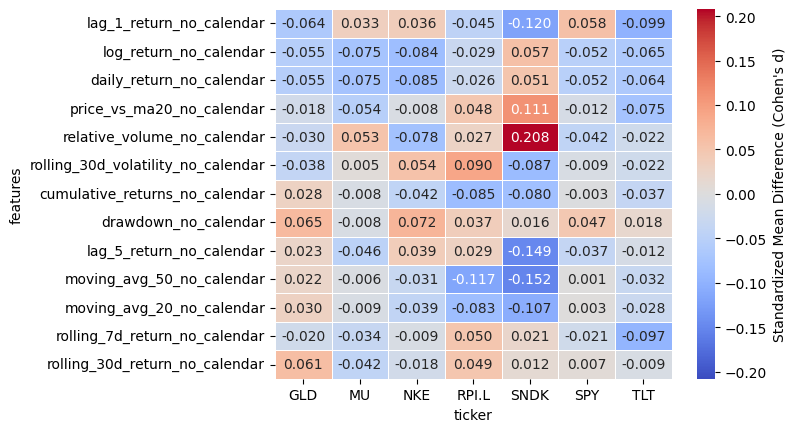

In [9]:
df_2 = df.copy()

target = f"target_direction_{CALENDAR}"
ticker = "ticker"

keep_columns = [
    column 
    for column in df_2.columns
    if column == ticker or column.endswith(f"_{CALENDAR}")
]

df_2 = df_2[keep_columns]
df_2 = df_2.drop(columns=[f"target_next_day_return_{CALENDAR}"], errors="ignore")

feature_columns = [
    column
    for column in df_2.columns
    if column.endswith(f"_{CALENDAR}") and column != target
]

results = []

for asset, ticker_df in df_2.groupby(ticker):

    down = ticker_df.loc[ticker_df[target] == 0, feature_columns]
    up = ticker_df.loc[ticker_df[target] == 1, feature_columns]

    down_mean = down.mean()
    up_mean = up.mean()

    down_median = down.median()
    up_median = up.median()

    diff_mean = up_mean - down_mean
    diff_median = up_median - down_median

    n_down = down.count()
    n_up = up.count()

    # Calculate variances using sample variance (n-1) rather than population variance (n)
    # Corrects for bias created / underestimation of varinace when sample is also used to calculate mean.
    down_var = down.var(ddof=1)
    up_var = up.var(ddof=1)

    # Calculate pooled standard deviation which gives insight into the natural spread in two groups.
    # Allows us to understand the magnitude of the difference in means relative to the natural spread of the data.
    pooled_std = np.sqrt(((n_down - 1) * down_var + (n_up - 1) * up_var) / (n_down + n_up - 2))

    # Use Cohens'd as standardised mean difference.
    cohens_d = diff_mean / pooled_std

    ticker_results = pd.DataFrame({
        "ticker": asset,
        "features": feature_columns,
        "down_mean": down_mean.values,
        "up_mean": up_mean.values,
        "down_median": down_median.values,
        "up_median": up_median.values,
        "diff_mean": diff_mean.values,
        "diff_median": diff_median.values,
        "n_down": n_down.values,
        "n_up": n_up.values,
        "standard_diff_mean": cohens_d.values,
        "n_up": n_up.values,
        "n_down": n_down.values,
    })

    results.append(ticker_results)

table = pd.concat(results, ignore_index=True)


directional_separation = table.pivot(
    index = "features",
    columns = "ticker",
    values = "standard_diff_mean"
)

feature_order = (
    directional_separation
    .abs()
    .median(axis=1)
    .sort_values(ascending=False)
    .index
)

directional_separation = directional_separation.loc[feature_order]

max_abs = table["standard_diff_mean"].abs().max().round(3)

sns.heatmap(
    directional_separation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=-max_abs,
    vmax=max_abs,
    cbar_kws={"label": "Standardized Mean Difference (Cohen's d)"}
)

# Positive Cohens'd indicates that up mean is higher than down.
# Negative Cohens'd indicates that down mean is higher than up.
# Because calculated as (up_mean - down_mean) / pooled_std, the sign of the value indicates the direction of the difference.

figure_count += 1
print(f"Figure {figure_count}: Directional-Separation Heatmap")
plt.show()

Cohens d represents a standardised difference between up and down days across features. this avoids large differences from non-percent features like moving average from being overrepresented. We calculate as up mean minus down mean over pooled standard deviation.

Figure 3 shows SNDK has the stronges differences. Relative volume has a relatively large differnce between up and down days. Aligned wiht our calculation, it indicates a higher relative volume prior to up days comapred to down days. Lag 5 return is higher prior to down days and 50d moving average is higher prior to down days. This indicates mean reversal trend where periods of growth are followed by falls.

# Ranked Directional Separation Summary

In [10]:
summary_rows = []

for feature, feature_df in table.groupby("features"):

    # Cohen's d values for this feature across all tickers
    signed_d = feature_df["standard_diff_mean"]
    absolute_d = signed_d.abs()

    # Row containing the strongest absolute Cohen's d
    max_row_index = absolute_d.idxmax()
    max_row = feature_df.loc[max_row_index]

    # Smallest class available for each ticker
    ticker_min_counts = feature_df[["n_down", "n_up"]].min(axis=1)

    # Ignore exact zero values when checking direction
    non_zero_signs = np.sign(signed_d[signed_d != 0])

    if non_zero_signs.empty:
        consistent_sign_tickers = 0
  
    else:
        positive_count = (non_zero_signs > 0).sum()
        negative_count = (non_zero_signs < 0).sum()

        consistent_sign_tickers = max(
            positive_count,
            negative_count
        )

        

    summary_rows.append({
        "features": feature,

        # Typical strength, ignoring direction
        "median_abs_standardised_difference": absolute_d.median(),

        # Typical direction and strength
        "median_signed_difference": signed_d.median(),

        # Strongest result for this feature
        "maximum_abs_difference": absolute_d.max(),

        # Ticker where the strongest result occurred
        "ticker_of_maximum": max_row["ticker"],

        # Number of tickers pointing in the majority direction
        "consistent_sign_tickers": consistent_sign_tickers,

        # Smallest up/down sample across all tickers
        "minimum_class_count": ticker_min_counts.min()
    })

feature_summary = pd.DataFrame(summary_rows)

rename_map = {
    "features": "Features",
    "median_abs_standardised_difference": "Median Absolute\nStandardised Difference",
    "median_signed_difference": "Median Signed\nStandardised Difference",
    "maximum_abs_difference": "Maximum Absolute\nStandardised Difference",
    "ticker_of_maximum": "Ticker of Maximum",
    "consistent_sign_tickers": "Number of Tickers\nwith Consistent Sign",
    "minimum_class_count": "Minimum Class Count"
}

feature_summary = feature_summary.rename(columns=rename_map)

decimal_cols = [
    "Median Absolute\nStandardised Difference",
    "Median Signed\nStandardised Difference",
    "Maximum Absolute\nStandardised Difference"
]

count_cols = [
    "Number of Tickers\nwith Consistent Sign",
    "Minimum Class Count"
]

styled_table = (
    feature_summary
    .sort_values("Median Absolute\nStandardised Difference", ascending=False)
    .style
    .format("{:.3f}", subset=decimal_cols)
    .format("{:.0f}", subset=count_cols)
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre"),
                ("text-align", "right"),
                ("vertical-align", "middle"),
                ("min-width", "120px"),
            ],
        }
    ])
    .hide(axis="index"
))

table_count += 1
print(f"Table {table_count}: Ranked Directional-Separation Summary")

display(styled_table)


Table 2: Ranked Directional-Separation Summary


Features,Median Absolute Standardised Difference,Median Signed Standardised Difference,Maximum Absolute Standardised Difference,Ticker of Maximum,Number of Tickers with Consistent Sign,Minimum Class Count
lag_1_return_no_calendar,0.058,-0.045,0.120,SNDK,4,161
log_return_no_calendar,0.057,-0.055,0.084,NKE,6,161
daily_return_no_calendar,0.055,-0.055,0.085,NKE,6,161
price_vs_ma20_no_calendar,0.048,-0.012,0.111,SNDK,5,150
relative_volume_no_calendar,0.042,-0.022,0.208,SNDK,4,150
rolling_30d_volatility_no_calendar,0.038,-0.009,0.090,RPI.L,4,144
cumulative_returns_no_calendar,0.037,-0.037,0.085,RPI.L,6,161
drawdown_no_calendar,0.037,0.037,0.072,NKE,6,161
lag_5_return_no_calendar,0.037,-0.012,0.149,SNDK,4,159
moving_avg_50_no_calendar,0.031,-0.031,0.152,SNDK,5,134


Table 2 shows there is generally no difference in features prior to up and down days. Features with the relatively highest signals are lag 1 returns, log returns, and daily returns. This suggests momentum as positive returns the previous day or day before tends to see a positive next day return.

While differences are minimal, they are generally consistent across tickers with most features sharing consistently positive or negative differences.

# Up vs Non Positive Distributions

Figure 4: lag_1_return_no_calendar Target Direction Split Distributions


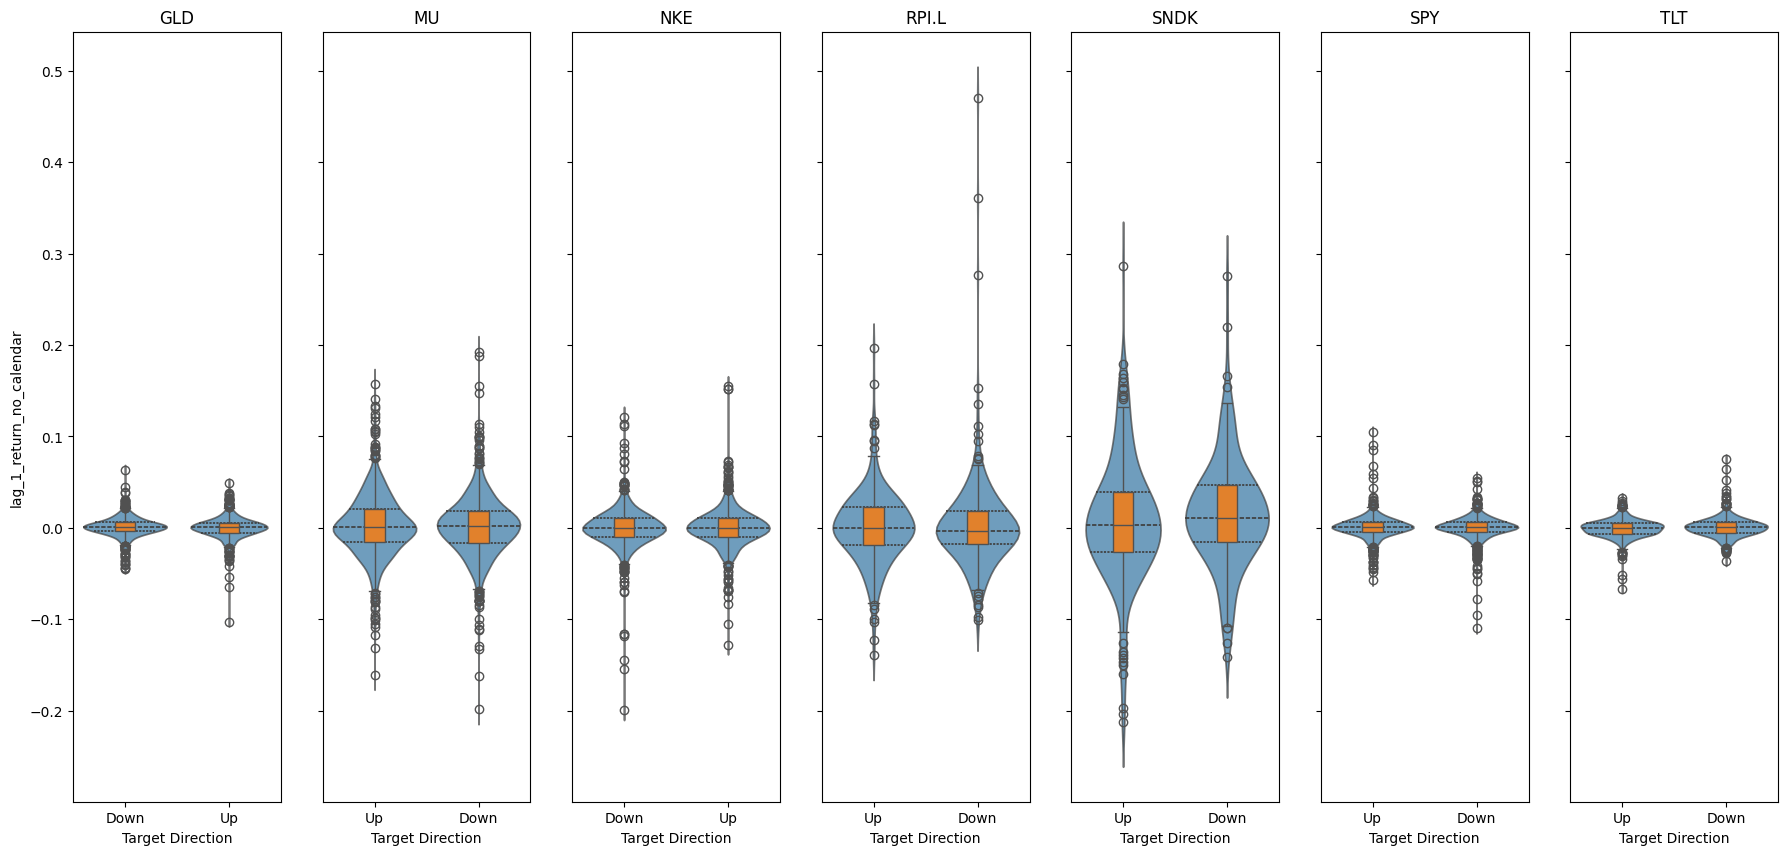

Figure 5: log_return_no_calendar Target Direction Split Distributions


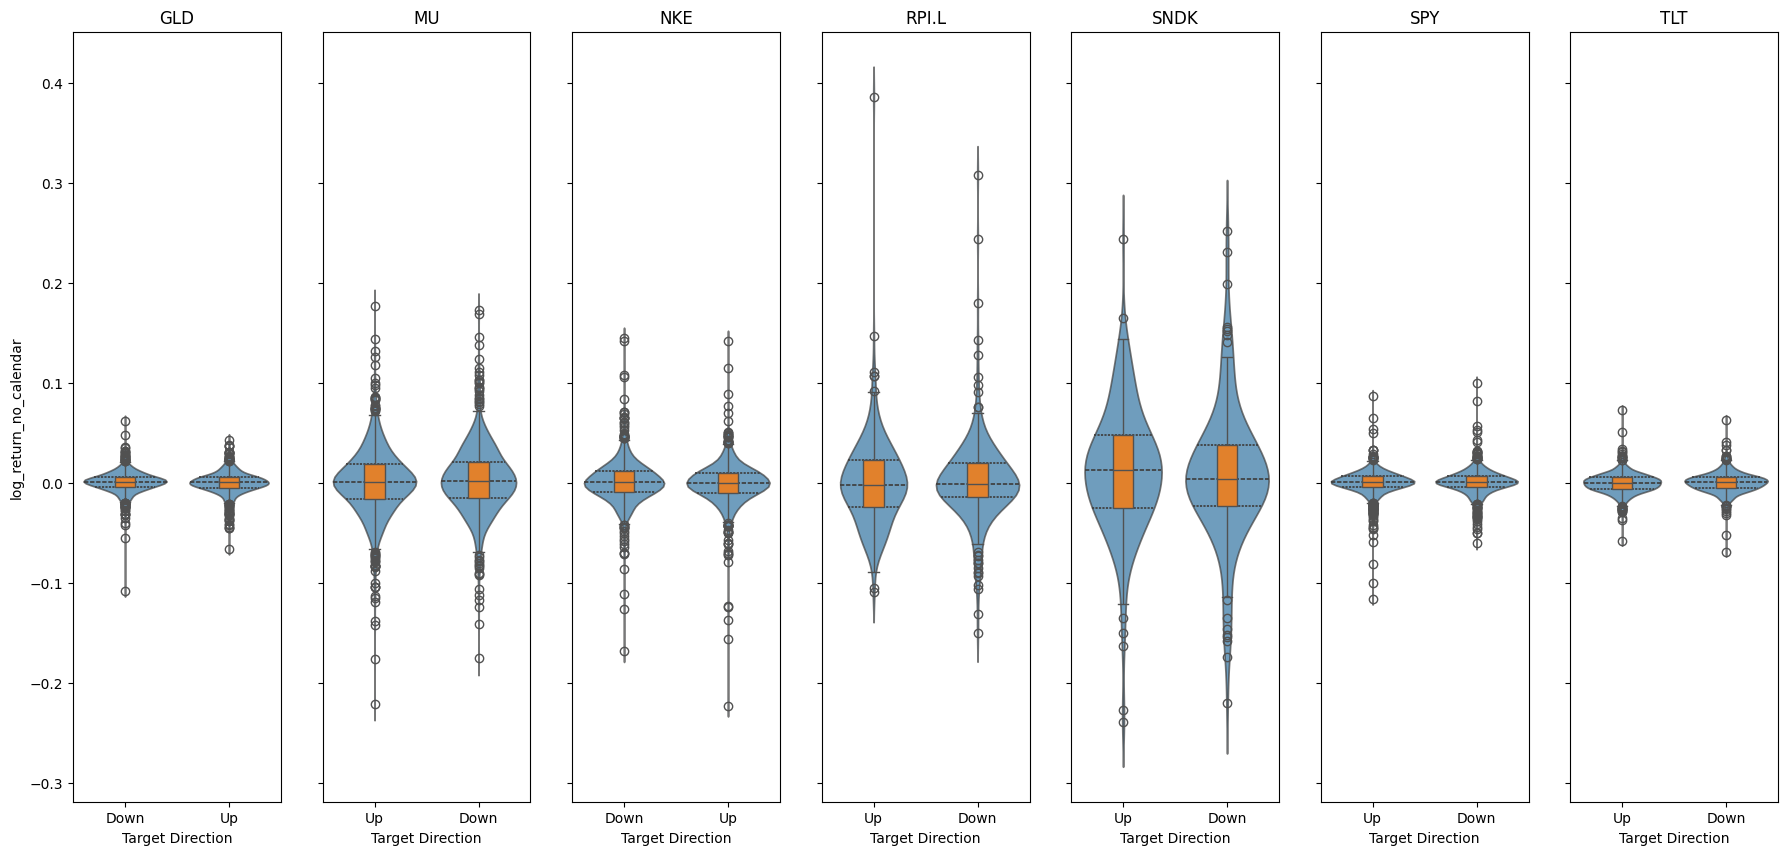

Figure 6: price_vs_ma20_no_calendar Target Direction Split Distributions


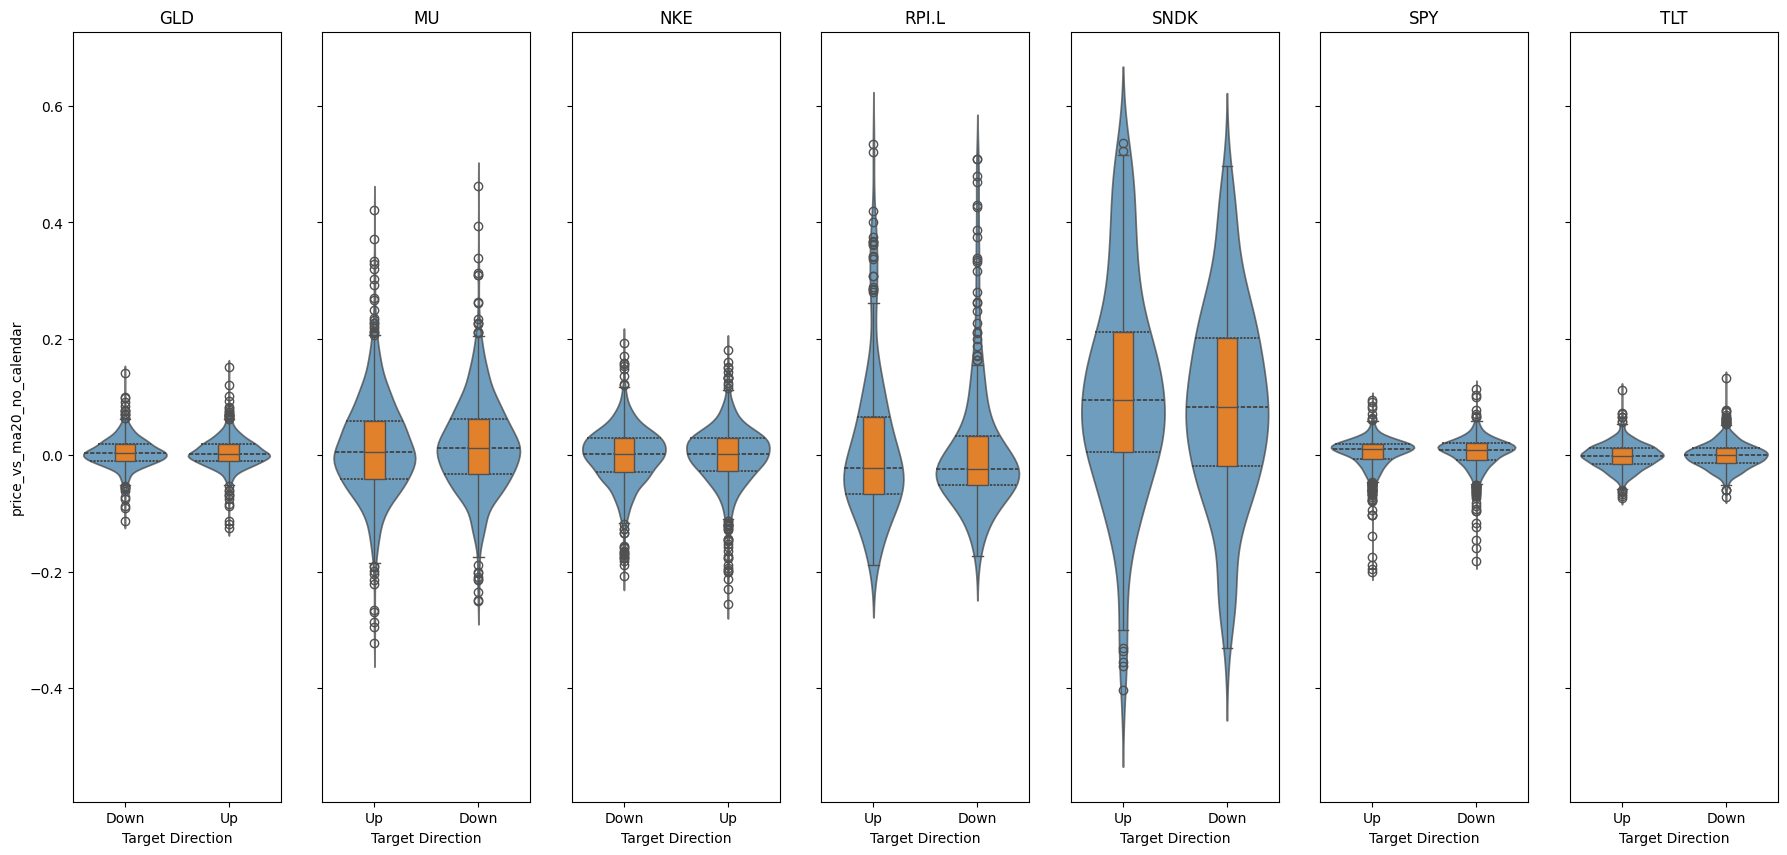

Figure 7: rolling_30d_volatility_no_calendar Target Direction Split Distributions


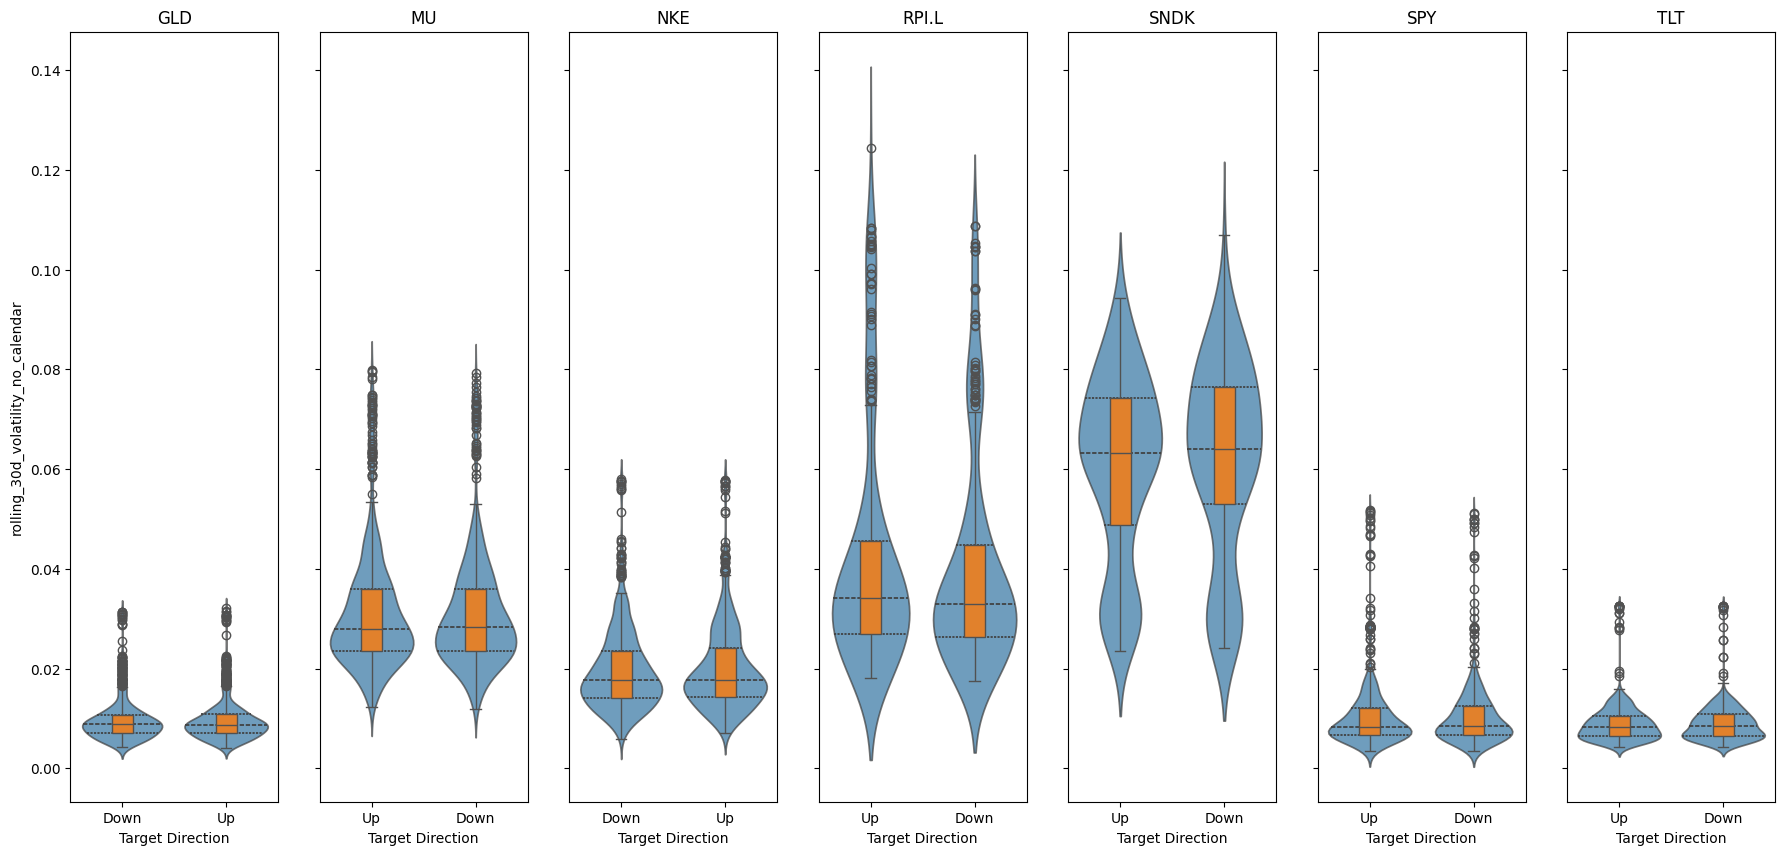

Figure 8: relative_volume_no_calendar Target Direction Split Distributions


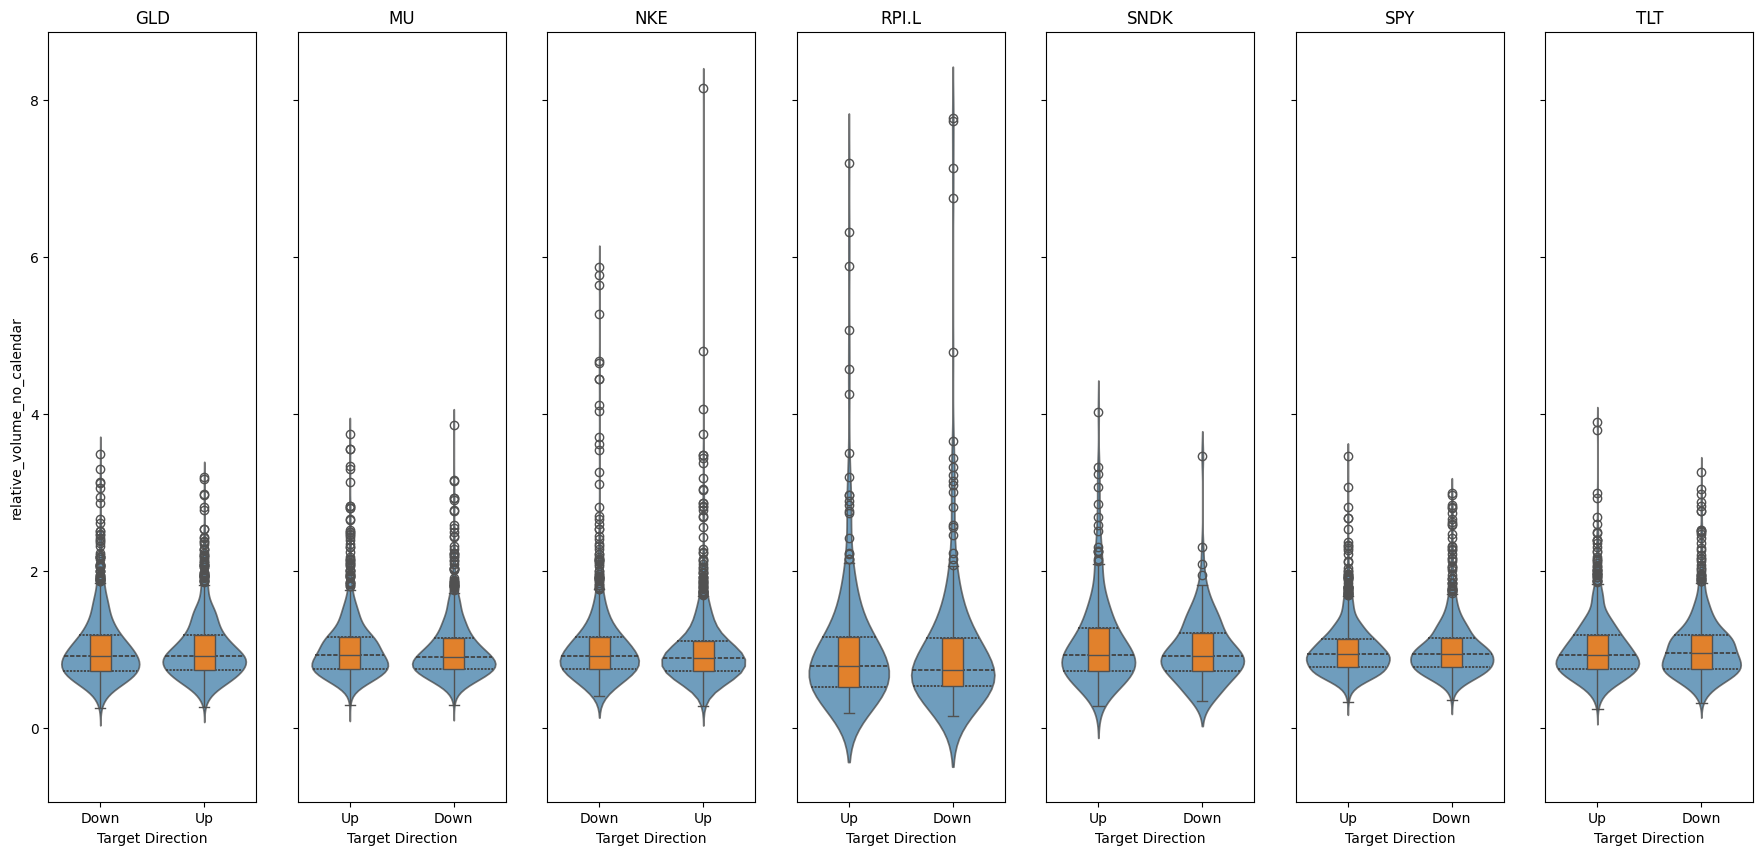

In [11]:
import matplotlib.pyplot as plt

df_3 = df.copy()

ticker = "ticker"

target_direction = "target_direction_no_calendar"

top_features = [
    "lag_1_return_no_calendar",
    "log_return_no_calendar",       # or daily_return, not necessarily both
    "price_vs_ma20_no_calendar",
    "rolling_30d_volatility_no_calendar",
    "relative_volume_no_calendar"
]

df_3[target_direction] = df_3[target_direction].map({
    0: "Down",
    1: "Up"
})

for feature in top_features:

    tickers = df_3[ticker].unique()

    fig, axes = plt.subplots(
                nrows = 1,
                ncols = len(tickers),
                figsize = (22, 10),
                sharey = True
            )

    for ax, (asset, group) in zip(axes, df_3.groupby(ticker)):

        sns.violinplot(
            data=group,
            x=target_direction,
            y=feature,
            inner="quartile",
            ax=ax,
            alpha=0.7
        )

        sns.boxplot(
            data=group,
            x=target_direction,
            y=feature,
            width=0.2,
            ax=ax
        )

        ax.set_title(asset)
        ax.set_xlabel("Target Direction")

    figure_count += 1
    print(f"Figure {figure_count}: {feature} Target Direction Split Distributions")

    plt.show()


These figures show the distributions of a chosen set of features across tickers. Figure 4 shows lag 1 return. Generally no large differences of the core distirbution but some trends across assets of the outlier trend relative to the target, mainly for SPY and TLT.

Figure 6 shows that RPI.L has a wider distribution of price vs moving average pior to up days compared to down days.

# Robustness Comparison

In [12]:
df_4 = df.copy()

ticker = "ticker"
date = "date"

keep_colunmns = [
    column 
    for column in df_4.columns
    if column == ticker or column == date or column.endswith(f"_{CALENDAR}")
]

target_return = "target_next_day_return_no_calendar"
target_direction = "target_direction_no_calendar"

df_4 = df_4[keep_colunmns]

date_range = (df_4.groupby(ticker)[date]
              .agg([
                    "min",
                    "max"
                ]))

common_start = date_range["min"].max()
common_end = date_range["max"].min()

df_5 = df_4[df_4["date"].between(common_start, common_end)].copy()

fp_df = df_4.copy()
cp_df = df_5.copy()

fp_spearman_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="spearman", numeric_only=True)[target_return]
        .drop(target_return)
        .rename_axis("variable")
    ) for ticker_value, group in fp_df.groupby(ticker)
})

fp_spearman_corr = (
    fp_spearman_corr
    .assign(
        median_fp_spearman_corr = lambda x:
            x[fp_spearman_corr.columns].abs().median(axis=1),

        fp_positive_count = lambda x:
            x[fp_spearman_corr.columns].gt(0).sum(axis=1),

        fp_negative_count = lambda x:
            x[fp_spearman_corr.columns].lt(0).sum(axis=1)
    )
)

fp_spearman_corr["fp_rank"] = (
    fp_spearman_corr["median_fp_spearman_corr"]
    # method "min" is equivalent to desntiy_rank() in SQL.
    # if gives tied ranks the same number then skips one before the next.
    .rank(ascending=False, method="min")
    .astype(int)
)

cp_spearman_corr = pd.DataFrame({
    ticker_value: (
        group
        .corr(method="spearman", numeric_only=True)[target_return]
        .drop(target_return)
        .rename_axis("variable")
    ) for ticker_value, group in cp_df.groupby(ticker)
})

cp_spearman_corr = (
    cp_spearman_corr
    .assign(
        median_cp_spearman_corr = lambda x:
            x[cp_spearman_corr.columns].abs().median(axis=1),

        cp_positive_count = lambda x:
            x[cp_spearman_corr.columns].gt(0).sum(axis=1),

        cp_negative_count = lambda x:
            x[cp_spearman_corr.columns].lt(0).sum(axis=1)
    )
)

cp_spearman_corr["cp_rank"] = (
    cp_spearman_corr["median_cp_spearman_corr"]
    .rank(ascending=False, method="min")
    .astype(int)
)

fp_v_cp = pd.concat(
    [fp_spearman_corr[["median_fp_spearman_corr", "fp_rank", "fp_positive_count", "fp_negative_count"]],
     cp_spearman_corr[["median_cp_spearman_corr", "cp_rank", "cp_positive_count", "cp_negative_count"]]],
     axis=1,
     join="inner"
)

fp_v_cp["fp_to_cp_rank_change"] = fp_v_cp["fp_rank"] - fp_v_cp["cp_rank"]

fp_v_cp["sign_change (positive:negative)"] = (
    fp_v_cp["fp_positive_count"].astype(str)
    + ":"
    + fp_v_cp["fp_negative_count"].astype(str)
    + " → "
    + fp_v_cp["cp_positive_count"].astype(str)
    + ":"
    + fp_v_cp["cp_negative_count"].astype(str)
)

summary_table = fp_v_cp[["median_fp_spearman_corr", "median_cp_spearman_corr", "cp_rank", "fp_to_cp_rank_change", "sign_change (positive:negative)"]]

rename_map = {
    "median_fp_spearman_corr": "Full Period\nSpearman Corr",
    "median_cp_spearman_corr": "Common Period\nSpearman Corr",
    "cp_rank": "Common Period\nRank",
    "fp_to_cp_rank_change": "Full to Common\nPeriod Rank Change",
    "sign_change (positive:negative)": "Positive:Negative\nSign Change"
}

summary_table = summary_table.rename(columns=rename_map).reset_index()

styled_table = (
    summary_table
    .sort_values("Full to Common\nPeriod Rank Change", ascending = False )
    .style
    .format({
        "Full to Common\nPeriod Rank Change": lambda x: f"{x:+.0f}" if x != 0 else 0,
        "Full Period\nSpearman Corr": "{:.3f}",
        "Common Period\nSpearman Corr": "{:.3f}"
    })
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre"),
                ("text-align", "right"),
                ("vertical-align", "middle"),
                ("min-width", "120px")
            ]
        }
    ]).hide(axis="index")
)
table_count += 1
print(f"Table {table_count}: Full vs Common Period Feature-Target Return Robustness")

display(styled_table)

# Stable → similar magnitude, similar rank, same sign
# Magnitude-sensitive → same sign but effect becomes much stronger/weaker
# Rank-sensitive → large movement in rank
# Regime/period-sensitive → sign changes
# Weak throughout → tiny effect in both periods


Table 3: Full vs Common Period Feature-Target Return Robustness


variable,Full Period Spearman Corr,Common Period Spearman Corr,Common Period Rank,Full to Common Period Rank Change,Positive:Negative Sign Change
relative_volume_no_calendar,0.011,0.055,3,+10,3:4 → 5:2
rolling_30d_return_no_calendar,0.010,0.036,7,+7,4:3 → 3:4
moving_avg_20_no_calendar,0.015,0.035,8,+4,3:4 → 1:6
moving_avg_50_no_calendar,0.019,0.043,5,+3,2:5 → 0:7
cumulative_returns_no_calendar,0.021,0.052,4,+2,2:5 → 0:7
rolling_7d_return_no_calendar,0.020,0.037,6,+1,2:5 → 1:6
drawdown_no_calendar,0.031,0.063,2,0,4:3 → 3:4
target_direction_no_calendar,0.864,0.861,1,0,7:0 → 7:0
price_vs_ma20_no_calendar,0.018,0.028,12,-1,2:5 → 2:5
lag_1_return_no_calendar,0.018,0.024,13,-4,3:4 → 3:4


Table 3 investigates the robustness of the trends we viewed across the whole period over a common period since 2 assets have later IPO dates and so less observations.

Over a common period spearman correlations are not significant. However, the relative strengths do change, represented by the change in rank across features, and median absolute correlations do rise. 

Relative volume ove a common period shows stronger correlations with the target and more tickers showing positive volume prior to gains. Over a common period, the return and volatility features become less significant.

In [13]:
target = "target_direction_no_calendar"
non_target = "target_next_day_return_no_calendar"
ticker = "ticker"

fp_df = fp_df.drop(columns=[non_target], errors="ignore").copy()
cp_df = cp_df.drop(columns=[non_target], errors="ignore").copy()

def create_table(type: str, df: pd.DataFrame) -> pd.DataFrame:

    target = "target_direction_no_calendar"
    ticker = "ticker" 

    feature_columns = [
        column
        for column in df_2.columns
        if column.endswith(f"_{CALENDAR}") and column != target
    ]

    results_table = []

    for asset, ticker_df in df.groupby(ticker):

        down = ticker_df.loc[ticker_df[target] == 0, feature_columns]
        up = ticker_df.loc[ticker_df[target] == 1, feature_columns]

        down_var = down.var(ddof=1)
        up_var = up.var(ddof=1)

        n_down = down.count()
        n_up = up.count()

        pooled_std = np.sqrt(((n_down - 1) * down_var + (n_up - 1) * up_var) / (n_down + n_up - 2))

        down_mean = down.mean()
        up_mean = up.mean()

        diff_mean = up_mean - down_mean

        cohens_d = diff_mean / pooled_std

        results = pd.DataFrame({
            "ticker": asset,
            "features": feature_columns,
            "standardised_diff_means": cohens_d.values
        })

        results_table.append(results)

    table = pd.concat(results_table, ignore_index=True)

    matrix = table.pivot(
        index="features",
        columns="ticker",
        values="standardised_diff_means"
    )

    table_1 = (
        matrix
        .assign(
            median_abs_standardised_diff = lambda x:
                x[matrix.columns].abs().median(axis=1).round(3),
            positive_count = lambda x:
                x[matrix.columns].gt(0).sum(axis=1),
            negative_count = lambda x:
                x[matrix.columns].lt(0).sum(axis=1)
        )
    )

    table_1.columns.name = None

    table_1 = table_1[["median_abs_standardised_diff", "positive_count", "negative_count"]]

    name_map = {
        "median_abs_standardised_diff": f"{type}_median_abs_standardised_diff",
        "positive_count": f"{type}_positive_count",
        "negative_count": f"{type}_negative_count"
    }

    table_1[f"{type}_rank"] = (
        table_1["median_abs_standardised_diff"]
        .rank(ascending=False, method="min").astype(int)
    )

    table_1 = table_1.rename(columns=name_map)

    return table_1

fp_table = create_table("fp", fp_df)
cp_table = create_table("cp", cp_df)

fp_v_cp = pd.concat(
    [fp_table, cp_table],
    axis=1,
    join="inner"
)

fp_v_cp["fp_to_cp_rank_change"] = fp_v_cp["fp_rank"] - fp_v_cp["cp_rank"]

fp_v_cp["sign_change (positive:negative)"] = (
    fp_v_cp["fp_positive_count"].astype(str)
    + ":"
    + fp_v_cp["fp_negative_count"].astype(str)
    + " → "
    + fp_v_cp["cp_positive_count"].astype(str)
    + ":"
    + fp_v_cp["cp_negative_count"].astype(str)
)

summary_table = fp_v_cp[["fp_median_abs_standardised_diff", "cp_median_abs_standardised_diff", "cp_rank", "fp_to_cp_rank_change", "sign_change (positive:negative)"]]

rename_map = {
    "fp_median_abs_standardised_diff": "Full Period\nStandardised Diff",
    "cp_median_abs_standardised_diff": "Common Period\nStandardised Diff",
    "cp_rank": "Common Period\nRank",
    "fp_to_cp_rank_change": "Full to Common\nPeriod Rank Change",
    "sign_change (positive:negative)": "Positive:Negative\nSign Change"
}

summary_table = summary_table.rename(columns=rename_map).reset_index()


styled_table = (
    summary_table
    .sort_values("Full to Common\nPeriod Rank Change", ascending = False )
    .style
    .format({
        "Full to Common\nPeriod Rank Change": lambda x: f"{x:+.0f}" if x != 0 else 0,
        "Full Period\nSpearman Corr": "{:.3f}",
        "Common Period\nSpearman Corr": "{:.3f}"
    })
    .set_table_styles([
        {
            "selector": "th.col_heading",
            "props": [
                ("white-space", "pre"),
                ("text-align", "right"),
                ("vertical-align", "middle"),
                ("min-width", "120px")
            ]
        }
    ]).hide(axis="index")
)
table_count += 1
print(f"Table {table_count}: Full vs Common Period Feature-Target Direction Robustness")

display(styled_table)


Table 4: Full vs Common Period Feature-Target Direction Robustness


features,Full Period Standardised Diff,Common Period Standardised Diff,Common Period Rank,Full to Common Period Rank Change,Positive:Negative Sign Change
moving_avg_20_no_calendar,0.030000,0.107000,2,+9,2:5 → 0:7
moving_avg_50_no_calendar,0.031000,0.122000,1,+9,2:5 → 1:6
cumulative_returns_no_calendar,0.037000,0.081000,4,+3,1:6 → 0:7
rolling_30d_volatility_no_calendar,0.038000,0.099000,3,+3,3:4 → 4:3
rolling_30d_return_no_calendar,0.018000,0.044000,11,+2,4:3 → 3:4
drawdown_no_calendar,0.037000,0.069000,6,+1,6:1 → 2:5
lag_5_return_no_calendar,0.037000,0.063000,8,-1,3:4 → 5:2
rolling_7d_return_no_calendar,0.021000,0.028000,13,-1,2:5 → 2:5
relative_volume_no_calendar,0.042000,0.068000,7,-2,3:4 → 5:2
lag_1_return_no_calendar,0.058000,0.072000,5,-4,3:4 → 4:3


Simiilarly, over a common period the standardised difference become more significant. Moving average appears as a strong indicator where moving average is higher prior to up days comapred to down days.